In [12]:
import matplotlib.pyplot as plt
import datetime as dt
import pandas as pd
import numpy as np
import scipy as sp

from pathlib import Path
import soundfile as sf
import json
import subprocess

from pyproj import Transformer


In [13]:
import folium

In [14]:
import UBNA_localize_process_GCC__20250505 as localize

In [15]:
HARD_DRIVE_LOC = Path('/Volumes/Elements/UBNA_array_tests2026')
experiment_folder = HARD_DRIVE_LOC / 'recover-20260604'
all_wav_files = list(experiment_folder.glob('STF_*/2026*0.WAV'))
all_sync_wav_files = list(experiment_folder.glob('STF_*/2026*_SYNC.WAV'))
all_csv_files = list(experiment_folder.glob('STF_*/2026*.CSV'))
all_wav_files, all_sync_wav_files, all_csv_files

([PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_200000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_203000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_210000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_213000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_220000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_223000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_230000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_233000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260604_000000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260604_003000.WAV'),


In [16]:
SD_CARD_TO_AUDIOMOTH_NUM = {'STF_026': '014', 'STF_028' : '045', 
                            'STF_057': '015', 'STF_109': '008', 
                            'STF_114': '040', 'STF_053': '032', 
                            'STF_021': '016', 'STF_116': '036', 
                            'STF_060': '004', 'STF_025': '042',  
                            'STF_027': '020',
                            'STF_113': '044', 'STF_030': '012'}
FREQ_UPPER_LIM = 6/8
SD_CARD_TO_AUDIOMOTH_NUM

{'STF_026': '014',
 'STF_028': '045',
 'STF_057': '015',
 'STF_109': '008',
 'STF_114': '040',
 'STF_053': '032',
 'STF_021': '016',
 'STF_116': '036',
 'STF_060': '004',
 'STF_025': '042',
 'STF_027': '020',
 'STF_113': '044',
 'STF_030': '012'}

In [17]:
AUDIOMOTH_AT_PATCHA = {'014':'A1 (top)', '045':'A1 (bottom)',
                       '015':'A4 (top)', '008':'A4 (bottom)',
                       '040':'A7 (top)', '032':'A7 (bottom)'}
AUDIOMOTH_AT_PATCHE = {'016':'E2 (top)', '036':'E2 (bottom)',
                       '004':'E4 (top)', '042':'E4 (bottom)',
                       '020':'E8 (alone)',
                       '044':'E9 (top)', '012':'E9 (bottom)'}

AUDIOMOTH_AT_ALLPATCHES = AUDIOMOTH_AT_PATCHA | AUDIOMOTH_AT_PATCHE

In [18]:
valid_sync_csv_files = dict.fromkeys(SD_CARD_TO_AUDIOMOTH_NUM, [])
for csv_file in all_csv_files:
    csv_file_dt = dt.datetime.strptime(csv_file.name, '%Y%m%d_%H%M%S.CSV')
    sd_card_name = csv_file.parts[-2]
    valid_sync_csv_files[sd_card_name] += [csv_file]
valid_sync_csv_files

{'STF_026': [PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_193756.CSV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_200000.CSV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_203000.CSV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_210000.CSV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_213000.CSV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_220000.CSV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_223000.CSV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_230000.CSV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_233000.CSV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260604_000

In [19]:
valid_sync_csv_files['STF_027']

[PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_193756.CSV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_200000.CSV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_203000.CSV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_210000.CSV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_213000.CSV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_220000.CSV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_223000.CSV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_230000.CSV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_233000.CSV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260604_000000.CSV'),
 PosixPath

In [20]:
import dask.dataframe  as dd

In [22]:
valid_sync_csv_files = {}

for sd_card_name in SD_CARD_TO_AUDIOMOTH_NUM:
    valid_sync_csv_files[sd_card_name] = []

for csv_file in all_csv_files:
    sd_card_name = csv_file.parts[-2]
    valid_sync_csv_files[sd_card_name].append(csv_file)

In [28]:
NOMINAL_SAMPLE_RATE = 192000
SECONDS_PER_30_MINUTES = 30 * 60

In [32]:
csv_data = pd.read_csv(valid_sync_csv_files["STF_027"][1])

valid_rows = (csv_data["PPS_NUMBER"] > 0) & (csv_data["STATUS"] == "A") & csv_data["LAST_RMC_GPS_TIME"].notna()
csv_data = csv_data.loc[valid_rows].copy()

csv_data["gps_time"] = pd.to_datetime(csv_data["LAST_RMC_GPS_TIME"])
csv_data["gps_interval_seconds"] = csv_data["gps_time"].diff().dt.total_seconds()

# The first valid row represents the first one-second PPS interval.
csv_data.loc[csv_data.index[0], "gps_interval_seconds"] = 1.0

csv_data["gps_elapsed_seconds"] = csv_data["gps_interval_seconds"].cumsum()
csv_data["expected_total_samples"] = csv_data["gps_elapsed_seconds"] * NOMINAL_SAMPLE_RATE
csv_data["clock_error_samples"] = csv_data["TOTAL_SAMPLES"] - csv_data["expected_total_samples"]
csv_data["clock_error_seconds"] = csv_data["clock_error_samples"] / NOMINAL_SAMPLE_RATE
csv_data

,PPS_NUMBER,AUDIOMOTH_TIME,SAMPLES,TOTAL_SAMPLES,TIMER_COUNT,BUFFERS_FILLED,BUFFERS_WRITTEN,LAST_RMC_AUDIOMOTH_TIME,LAST_RMC_GPS_TIME,STATUS,...,LAT_DIR,LONG_DEG,LONG_MIN,LONG_DIR,gps_time,gps_interval_seconds,gps_elapsed_seconds,expected_total_samples,clock_error_samples,clock_error_seconds
1,1,2026-06-04T20:30:00.999,191965,191965,54,11,11,2026-06-04T20:30:00.361,2026-06-04T20:30:00.000,A,...,N,122.0,17.6914,W,2026-06-04 20:30:00,1.0,1.0,192000.0,-35.0,-0.000182
2,2,2026-06-04T20:30:01.999,191964,383929,179,23,23,2026-06-04T20:30:01.590,2026-06-04T20:30:01.000,A,...,N,122.0,17.6914,W,2026-06-04 20:30:01,1.0,2.0,384000.0,-71.0,-0.000370
3,3,2026-06-04T20:30:02.999,191965,575894,56,35,35,2026-06-04T20:30:02.367,2026-06-04T20:30:02.000,A,...,N,122.0,17.6914,W,2026-06-04 20:30:02,1.0,3.0,576000.0,-106.0,-0.000552
4,4,2026-06-04T20:30:03.999,191964,767858,182,46,46,2026-06-04T20:30:03.369,2026-06-04T20:30:03.000,A,...,N,122.0,17.6914,W,2026-06-04 20:30:03,1.0,4.0,768000.0,-142.0,-0.000740
5,5,2026-06-04T20:30:04.999,191965,959823,59,58,58,2026-06-04T20:30:04.367,2026-06-04T20:30:04.000,A,...,N,122.0,17.6914,W,2026-06-04 20:30:04,1.0,5.0,960000.0,-177.0,-0.000922
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1661,1661,2026-06-04T20:57:55.967,191964,321732495,231,19636,19636,2026-06-04T20:57:55.341,2026-06-04T20:57:55.000,A,...,N,122.0,17.6926,W,2026-06-04 20:57:55,1.0,1676.0,321792000.0,-59505.0,-0.309922
1662,1662,2026-06-04T20:57:56.967,191965,321924460,96,19648,19648,2026-06-04T20:57:56.554,2026-06-04T20:57:56.000,A,...,N,122.0,17.6926,W,2026-06-04 20:57:56,1.0,1677.0,321984000.0,-59540.0,-0.310104
1663,1663,2026-06-04T20:57:57.967,191964,322116424,210,19660,19660,2026-06-04T20:57:57.332,2026-06-04T20:57:57.000,A,...,N,122.0,17.6926,W,2026-06-04 20:57:57,1.0,1678.0,322176000.0,-59576.0,-0.310292
1664,1664,2026-06-04T20:57:58.967,191965,322308389,75,19672,19672,2026-06-04T20:57:58.341,2026-06-04T20:57:58.000,A,...,N,122.0,17.6926,W,2026-06-04 20:57:58,1.0,1679.0,322368000.0,-59611.0,-0.310474


In [47]:
1800*0.182

327.59999999999997

In [33]:
gps_duration_seconds = csv_data["gps_elapsed_seconds"].iloc[-1]
final_clock_error_seconds = csv_data["clock_error_seconds"].iloc[-1]
observed_sample_rate = csv_data["TOTAL_SAMPLES"].iloc[-1] / gps_duration_seconds
clock_error_per_30_minutes = final_clock_error_seconds / gps_duration_seconds * SECONDS_PER_30_MINUTES

In [44]:
clock_drift_rows = []
clock_drift_timeseries = {}

for csv_file in sorted(valid_sync_csv_files["STF_021"]):
    csv_data = pd.read_csv(csv_file)

    valid_rows = (csv_data["PPS_NUMBER"] > 0) & (csv_data["STATUS"] == "A") & csv_data["LAST_RMC_GPS_TIME"].notna()
    csv_data = csv_data.loc[valid_rows].copy()

    csv_data["gps_time"] = pd.to_datetime(csv_data["LAST_RMC_GPS_TIME"])
    csv_data["gps_interval_seconds"] = csv_data["gps_time"].diff().dt.total_seconds()

    # The first valid row represents the first one-second PPS interval.
    csv_data.loc[csv_data.index[0], "gps_interval_seconds"] = 1.0

    csv_data["gps_elapsed_seconds"] = csv_data["gps_interval_seconds"].cumsum()
    csv_data["expected_total_samples"] = csv_data["gps_elapsed_seconds"] * NOMINAL_SAMPLE_RATE
    csv_data["clock_error_samples"] = csv_data["TOTAL_SAMPLES"] - csv_data["expected_total_samples"]
    csv_data["clock_error_seconds"] = csv_data["clock_error_samples"] / NOMINAL_SAMPLE_RATE

    gps_duration_seconds = csv_data["gps_elapsed_seconds"].iloc[-1]
    final_clock_error_seconds = csv_data["clock_error_seconds"].iloc[-1]
    observed_sample_rate = csv_data["TOTAL_SAMPLES"].iloc[-1] / gps_duration_seconds

    clock_drift_rows.append({
        "file": csv_file.name,
        "gps_duration_seconds": gps_duration_seconds,
        "observed_sample_rate": observed_sample_rate,
        "final_clock_error_seconds": final_clock_error_seconds
        })

    clock_drift_timeseries[csv_file.name] = csv_data

clock_drift_summary = pd.DataFrame(clock_drift_rows)
clock_drift_summary

,file,gps_duration_seconds,observed_sample_rate,final_clock_error_seconds
0,20260603_193756.CSV,1204.0,191966.210133,-0.211891
1,20260603_200000.CSV,1680.0,191966.308929,-0.294797
2,20260603_203000.CSV,1680.0,191966.356548,-0.294380
3,20260603_210000.CSV,1680.0,191966.358333,-0.294365
4,20260603_213000.CSV,1680.0,191966.277976,-0.295068
5,20260603_220000.CSV,1680.0,191966.225000,-0.295531
6,20260603_223000.CSV,1680.0,191966.457738,-0.293495
7,20260603_230000.CSV,1680.0,191966.283929,-0.295016
8,20260603_233000.CSV,1680.0,191966.310714,-0.294781
9,20260604_000000.CSV,1680.0,191966.318452,-0.294714


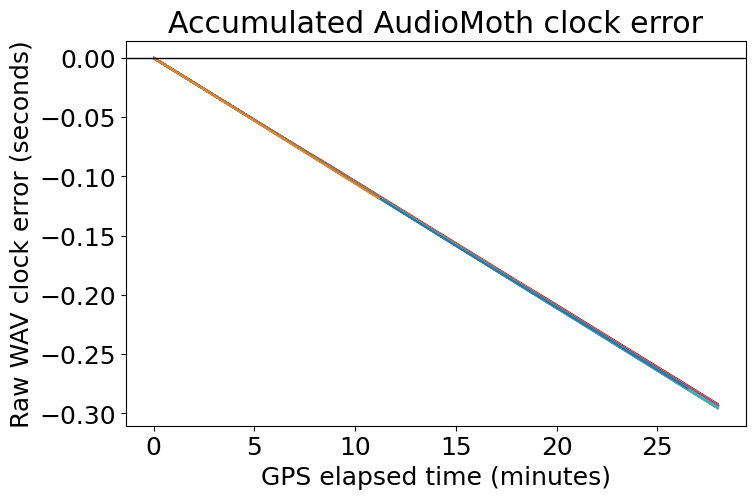

In [45]:
fig, ax = plt.subplots(figsize=(8, 5))
plt.rcParams.update({'font.size': 18})

for file_name, csv_data in clock_drift_timeseries.items():
    elapsed_minutes = csv_data["gps_elapsed_seconds"] / 60
    ax.plot(elapsed_minutes, csv_data["clock_error_seconds"], label=file_name)

ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("GPS elapsed time (minutes)")
ax.set_ylabel("Raw WAV clock error (seconds)")
ax.set_title("Accumulated AudioMoth clock error")
plt.show()